<a href="https://colab.research.google.com/github/fboldt/aulasml/blob/master/aula02b_classificador_linear_multiclasse.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split

X, y = load_wine(return_X_y=True)
X_reduced = X[:, [6,9]]
X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, test_size=0.2, random_state=42)

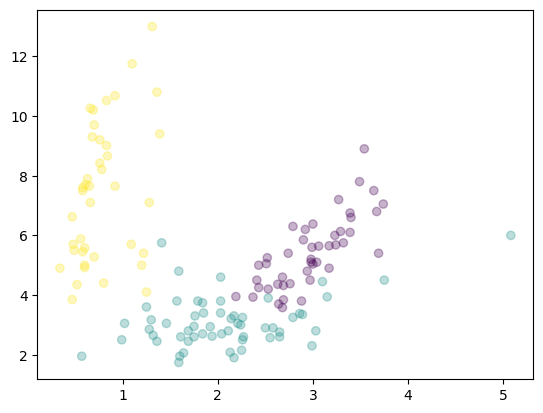

In [6]:
from matplotlib import pyplot as plt

plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="viridis", alpha=0.3)
plt.show()
#

In [8]:
set(y_train)

{np.int64(0), np.int64(1), np.int64(2)}

In [17]:
import numpy as np

y_hot = np.zeros((len(y_train), len(set(y_train))))
labels = sorted(list(set(y_train)))
for i, label in enumerate(labels):
    idxs = np.where(y_train == label)[0]
    y_hot[idxs, i] = 1
print(y_train[:10])
print(y_hot[:10])

[2 2 1 2 0 1 1 1 2 0]
[[0. 0. 1.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]]


In [20]:
from sklearn.base import BaseEstimator, ClassifierMixin
import numpy as np
from sklearn.metrics import accuracy_score

def include_bias(X):
  return np.c_[np.ones(len(X)), X]

def one_hot_encode(y):
  y_hot = np.zeros((len(y), len(set(y))))
  labels = sorted(list(set(y)))
  for i, label in enumerate(labels):
    idxs = np.where(y == label)[0]
    y_hot[idxs, i] = 1
  return y_hot, labels

class LinearClassifier(BaseEstimator, ClassifierMixin):
  def fit(self, X, y):
    self.y_hot, self.labels = one_hot_encode(y)
    Xb = include_bias(X)
    self.w = np.linalg.pinv(Xb) @ self.y_hot
    return self
  def predict(self, X):
    Xb = include_bias(X)
    y_pred = Xb @ self.w
    y_pred = np.argmax(y_pred, axis=1)
    return np.array([self.labels[i] for i in y_pred])

model = LinearClassifier()
model.fit(X_train, y_train)
print(model.w)
y_pred = model.predict(X_test)
accuracy_score(y_test, y_pred)

[[-0.61104821  1.22996937  0.38107884]
 [ 0.33360723 -0.03878215 -0.29482508]
 [ 0.05141373 -0.14847237  0.09705864]]


0.8611111111111112

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33)

model = LinearClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy_score(y_test, y_pred)

1.0